In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
prices = pd.read_csv("data/dk2_prices.csv", parse_dates=["TimeDK"])
prices.head()

,TimeUTC,TimeDK,PriceArea,DayAheadPriceEUR,DayAheadPriceDKK
0,2026-09-16 21:45:00,2026-09-16 23:45:00,DK2,167.809998,1254.463640
1,2026-09-16 21:30:00,2026-09-16 23:30:00,DK2,183.389999,1370.931938
2,2026-09-16 21:15:00,2026-09-16 23:15:00,DK2,186.860001,1396.871937
3,2026-09-16 21:00:00,2026-09-16 23:00:00,DK2,187.490005,1401.581532
4,2026-09-16 20:45:00,2026-09-16 22:45:00,DK2,187.979996,1405.244460


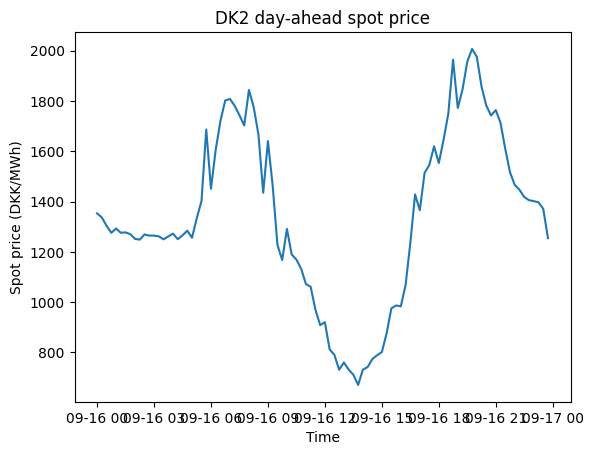

In [3]:
plt.plot(prices["TimeDK"], prices["DayAheadPriceDKK"])
plt.xlabel("Time")
plt.ylabel("Spot price (DKK/MWh)")
plt.title("DK2 day-ahead spot price")
plt.show()

In [4]:
wind = pd.read_csv("data/dk2_wind.csv", parse_dates=["Minutes5DK"])
wind["TotalWindPower"] = wind["OffshoreWindPower"] + wind["OnshoreWindPower"]
wind.head()

,Minutes5UTC,Minutes5DK,PriceArea,ProductionLt100MW,ProductionGe100MW,OffshoreWindPower,OnshoreWindPower,SolarPower,ExchangeGreatBelt,ExchangeGermany,ExchangeNetherlands,ExchangeGreatBritain,ExchangeNorway,ExchangeSweden,BornholmSE4,TotalWindPower
0,2026-09-16 21:55:00,2026-09-16 23:55:00,DK2,80.339996,578.419983,698.239990,236.880005,0.12,90.940002,-749.409973,NaN,NaN,NaN,389.519989,1.86,935.119995
1,2026-09-16 21:50:00,2026-09-16 23:50:00,DK2,79.169998,576.090027,659.650024,243.990005,0.10,95.290001,-741.229980,NaN,NaN,NaN,445.910004,3.61,903.640029
2,2026-09-16 21:45:00,2026-09-16 23:45:00,DK2,78.900002,574.150024,645.809998,252.300003,0.27,110.650002,-740.609985,NaN,NaN,NaN,415.000000,3.92,898.110001
3,2026-09-16 21:40:00,2026-09-16 23:40:00,DK2,78.230003,574.690002,662.500000,255.740005,0.29,110.750000,-768.049988,NaN,NaN,NaN,408.600006,3.27,918.240005
4,2026-09-16 21:35:00,2026-09-16 23:35:00,DK2,77.400002,575.950012,685.440002,245.080002,1.17,109.930000,-773.409973,NaN,NaN,NaN,455.890015,1.42,930.520004


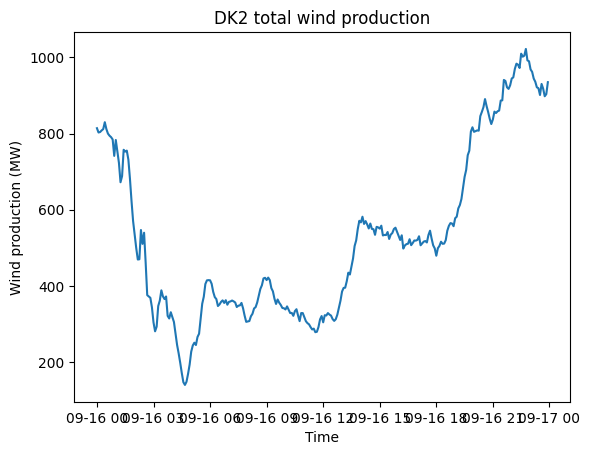

In [5]:
plt.plot(wind["Minutes5DK"], wind["TotalWindPower"])
plt.xlabel("Time")
plt.ylabel("Wind production (MW)")
plt.title("DK2 total wind production")
plt.show()

In [6]:
print("Price date range:", prices["TimeDK"].min(), "to", prices["TimeDK"].max())
print("Wind date range:", wind["Minutes5DK"].min(), "to", wind["Minutes5DK"].max())

Price date range: 2026-09-16 00:00:00 to 2026-09-16 23:45:00
Wind date range: 2026-09-16 00:00:00 to 2026-09-16 23:55:00


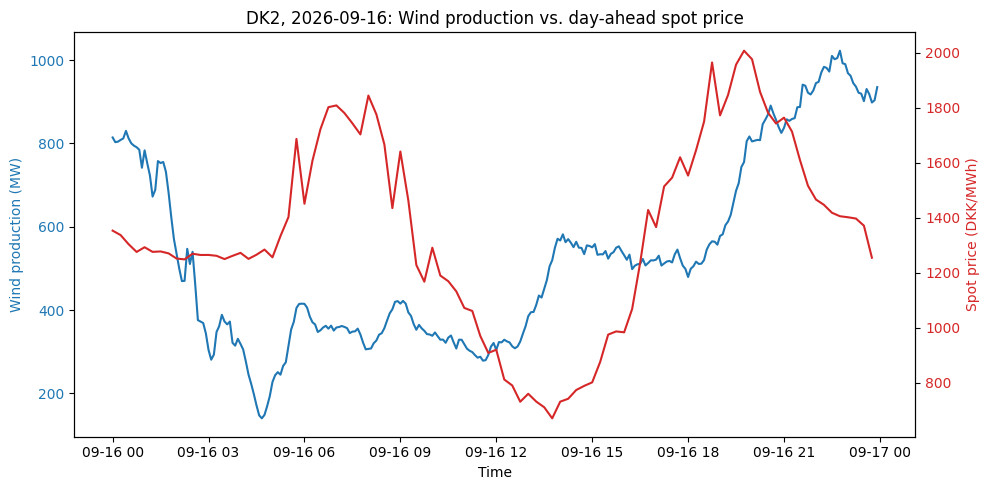

In [7]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(wind["Minutes5DK"], wind["TotalWindPower"], color="tab:blue", label="Wind production (MW)")
ax1.set_xlabel("Time")
ax1.set_ylabel("Wind production (MW)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(prices["TimeDK"], prices["DayAheadPriceDKK"], color="tab:red", label="Spot price (DKK/MWh)")
ax2.set_ylabel("Spot price (DKK/MWh)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

chart_date = prices["TimeDK"].dt.date.iloc[0]
plt.title(f"DK2, {chart_date}: Wind production vs. day-ahead spot price")
fig.tight_layout()
plt.savefig("data/wind_vs_price.png")
plt.show()